In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
import pmdarima
from sktime.forecasting.arima import AutoARIMA, ARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_correlations
from sktime.performance_metrics.forecasting import mean_absolute_scaled_error,mean_absolute_percentage_error
import Levenshtein

In [2]:
data = pd.read_csv('parkingLot.csv')
data = data.dropna()
data['vehicle_no'] = data['vehicle_no'].apply(lambda x: 'MH' + x[2:] if not x.startswith('MH') else x)
print(data.shape)

data.head()

(106253, 3)


,vehicle_no,timestamp,camera_id
0,MHUN7063,2024-09-12 05:00:00,1
1,MHYN4677,2024-09-12 05:00:00,1
2,MHEL6595,2024-09-12 05:00:00,1
3,MHNQ2590,2024-09-12 05:00:00,1
4,MHHA0518,2024-09-12 05:00:00,1


In [3]:
entry_data = data[data['camera_id'] == 1]
exit_data = data[data['camera_id'] == 2]



entry_not_exit = entry_data[~entry_data['vehicle_no'].isin(exit_data['vehicle_no'])]
exit_not_entry = exit_data[~exit_data['vehicle_no'].isin(entry_data['vehicle_no'])]

print("Vehicles in entry but not exit:", entry_not_exit.shape[0])
print("Vehicles in exit but not entry:", exit_not_entry.shape[0])


Vehicles in entry but not exit: 454
Vehicles in exit but not entry: 751


In [4]:
matches = []

for entry in entry_not_exit['vehicle_no']:
    for exit in exit_not_entry['vehicle_no']:
        if Levenshtein.distance(entry, exit) == 1:
            matches.append((entry, exit))

print("Matches found:", len(matches))
print(matches)

for entry, exit in matches:
    exit_data.loc[exit_data['vehicle_no'] == exit, 'vehicle_no'] = entry

# print(exit_data.head())
entry_not_exit = entry_data[~entry_data['vehicle_no'].isin(exit_data['vehicle_no'])]
exit_not_entry = exit_data[~exit_data['vehicle_no'].isin(entry_data['vehicle_no'])]

print("Vehicles in entry but not exit:", entry_not_exit.shape[0])
print("Vehicles in exit but not entry:", exit_not_entry.shape[0])

entry_data = entry_data[~entry_data['vehicle_no'].isin(entry_not_exit['vehicle_no'])]
print("Updated entry_data shape:", entry_data.shape)



Matches found: 387
[('MHHA0518', 'MHRA0518'), ('MHFT7338', 'MHFT733P'), ('MHWY3805', 'MHWY380W'), ('MHSK2899', 'MHSK2699'), ('MHHY5919', 'MHH45919'), ('MHUX0506', 'MHUX0502'), ('MHFU0729', 'MHFUZ729'), ('MHEQ3171', 'MHJQ3171'), ('MHHM4699', 'MHHM2699'), ('MHRB1492', 'MHR91492'), ('MHGK1011', 'MHGK1019'), ('MHHM4015', 'MHHK4015'), ('MHEX1429', 'MHEF1429'), ('MHIU3086', 'MHIU3E86'), ('MHWA0515', 'MHWAM515'), ('MHTW6742', 'MHGW6742'), ('MHMV9083', 'MHM59083'), ('MHPP4514', 'MH2P4514'), ('MHXQ3527', 'MHX33527'), ('MHTS3139', 'MHTS3639'), ('MHCQ1044', 'MHOQ1044'), ('MHKT5723', 'MHKN5723'), ('MHUL5410', 'MHUL5W10'), ('MHZR3297', 'MHZR32O7'), ('MHCW9511', 'MHCW9311'), ('MHRG2646', 'MHRGB646'), ('MHMW2907', 'MHMW2X07'), ('MHKF1151', 'MHK91151'), ('MHAQ9472', 'MHAQ947G'), ('MHJU0967', 'MHJZ0967'), ('MHDF8441', 'MHDF8T41'), ('MHLN8171', 'MHLA8171'), ('MHBU3667', 'MHBU366K'), ('MHUD6562', 'MHUDD562'), ('MHRI2902', 'MHRI2T02'), ('MHGP6902', 'MHGP69W2'), ('MHGM9704', 'MHGG9704'), ('MHSW4959', 'MHSW

In [5]:
# Merge entry_data and exit_data on vehicle_no
merged_data = pd.merge(entry_data, exit_data, on='vehicle_no', suffixes=('_entry', '_exit'))
print(merged_data)
# Convert timestamp columns to datetime
merged_data['timestamp_entry'] = pd.to_datetime(merged_data['timestamp_entry'])
merged_data['timestamp_exit'] = pd.to_datetime(merged_data['timestamp_exit'])


# Calculate time difference in hours with (exit-entry+24)%24
merged_data['time_spent'] = ((merged_data['timestamp_exit'] - merged_data['timestamp_entry']).dt.total_seconds() / 3600 + 24) % 24
# Extract date from timestamp_entry
merged_data['date'] = merged_data['timestamp_entry'].dt.date

# Group by date and calculate average time spent
average_time_spent = merged_data.groupby('date')['time_spent'].mean().reset_index()

print(average_time_spent)



      vehicle_no      timestamp_entry  camera_id_entry       timestamp_exit  \
0       MHUN7063  2024-09-12 05:00:00                1  2024-09-12 08:00:00   
1       MHYN4677  2024-09-12 05:00:00                1  2024-09-12 08:00:00   
2       MHEL6595  2024-09-12 05:00:00                1  2024-09-12 08:00:00   
3       MHNQ2590  2024-09-12 05:00:00                1  2024-09-12 08:20:00   
4       MHHA0518  2024-09-12 05:00:00                1  2024-09-12 08:40:00   
...          ...                  ...              ...                  ...   
53271   MHVY8418  2024-11-13 20:00:00                1  2024-11-14 00:00:00   
53272   MHDF3718  2024-11-13 20:00:00                1  2024-11-14 00:00:00   
53273   MHQJ4009  2024-11-13 20:00:00                1  2024-11-14 00:00:00   
53274   MHPN3450  2024-11-13 20:00:00                1  2024-11-14 00:00:00   
53275   MHBB9719  2024-11-13 20:00:00                1  2024-11-14 00:00:00   

       camera_id_exit  
0                   2  
1  

In [6]:
# Splitting the data into training and testing sets
train_data = average_time_spent.iloc[:56]
test_data = average_time_spent.iloc[56:]

print("Training Data:")
print(train_data)
print("\nTesting Data:")
print(test_data)

Training Data:
          date  time_spent
0   2024-09-12    4.249064
1   2024-09-13    6.492470
2   2024-09-14    8.264368
3   2024-09-15    8.975685
4   2024-09-16    8.393725
5   2024-09-17    6.902349
6   2024-09-18    4.984211
7   2024-09-19    3.290062
8   2024-09-20    2.550251
9   2024-09-21    2.766472
10  2024-09-22    4.064975
11  2024-09-23    5.676659
12  2024-09-24    7.203726
13  2024-09-25    8.070199
14  2024-09-26    7.972332
15  2024-09-27    6.984713
16  2024-09-28    5.595449
17  2024-09-29    4.198830
18  2024-09-30    3.319272
19  2024-10-01    3.257207
20  2024-10-02    4.004970
21  2024-10-03    5.234626
22  2024-10-04    6.419186
23  2024-10-05    7.354276
24  2024-10-06    7.480963
25  2024-10-07    6.946175
26  2024-10-08    5.944149
27  2024-10-09    4.788609
28  2024-10-10    3.995566
29  2024-10-11    3.682343
30  2024-10-12    4.045512
31  2024-10-13    4.952334
32  2024-10-14    5.949846
33  2024-10-15    6.829719
34  2024-10-16    7.051168
35  2024-10-1

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='time_spent'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

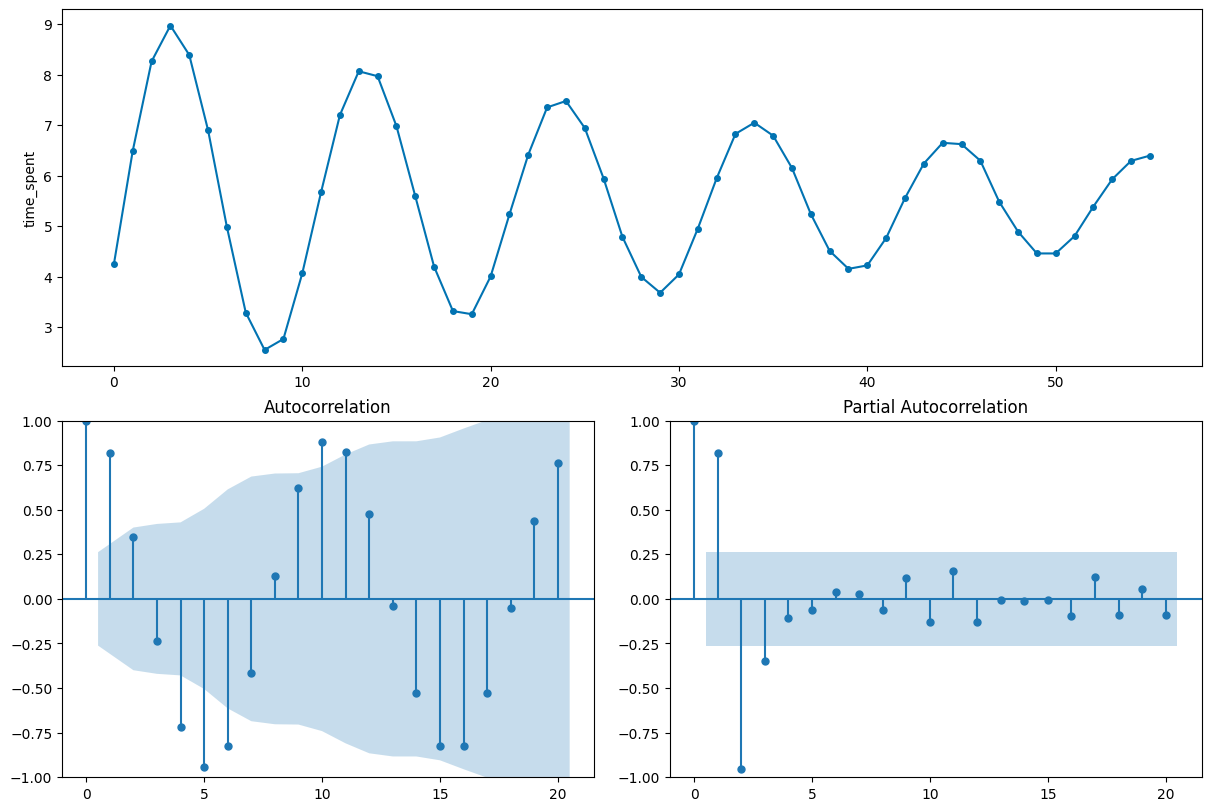

In [7]:
plot_correlations(train_data['time_spent'], lags=20)


In [8]:
forecaster = AutoARIMA(sp=14,suppress_warnings=True)

forecaster.fit(train_data['time_spent'])
forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   56
Model:             SARIMAX(3, 0, 1)x(0, 0, 1, 14)   Log Likelihood                  62.671
Date:                            Sun, 27 Oct 2024   AIC                           -111.341
Time:                                    18:59:59   BIC                            -97.164
Sample:                                         0   HQIC                          -105.845
                                             - 56                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.7845      0.384      9.843      0.000       3.031       4.538
ar.L1          0.7202      0.189      3.814      0.000       0.350       1.090
ar.L2          0.5051      0.307      1.646      0.100      -0.096       1.106
ar.L3         -0.9135      0.187     -4.897      0.000      -1.279      -0.548
ma.L1          0.6664      0.214      3.114      0.002       0.247       1.086
ma.S.L14      -0.8136      0.502     -1.620      0.105      -1.798       0.171
sigma2         0.0040      0.002      1.931      0.053   -5.95e-05       0.008
===================================================================================
Ljung-Box (L1) (Q):                   1.53   Jarque-Bera (JB):                 1.77
Prob(Q):                              0.22   Prob(JB):                         0.41
Heteroskedasticity (H):               0.48   Skew:                            -0.00
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

56    6.153664
57    5.756296
58    5.235586
59    4.813572
60    4.610125
61    4.813149
62    5.184411
Name: time_spent, dtype: float64
          date  time_spent
56  2024-11-07    6.171605
57  2024-11-08    5.677057
58  2024-11-09    5.188556
59  2024-11-10    4.765471
60  2024-11-11    4.706330
61  2024-11-12    4.910319
62  2024-11-13    5.205030


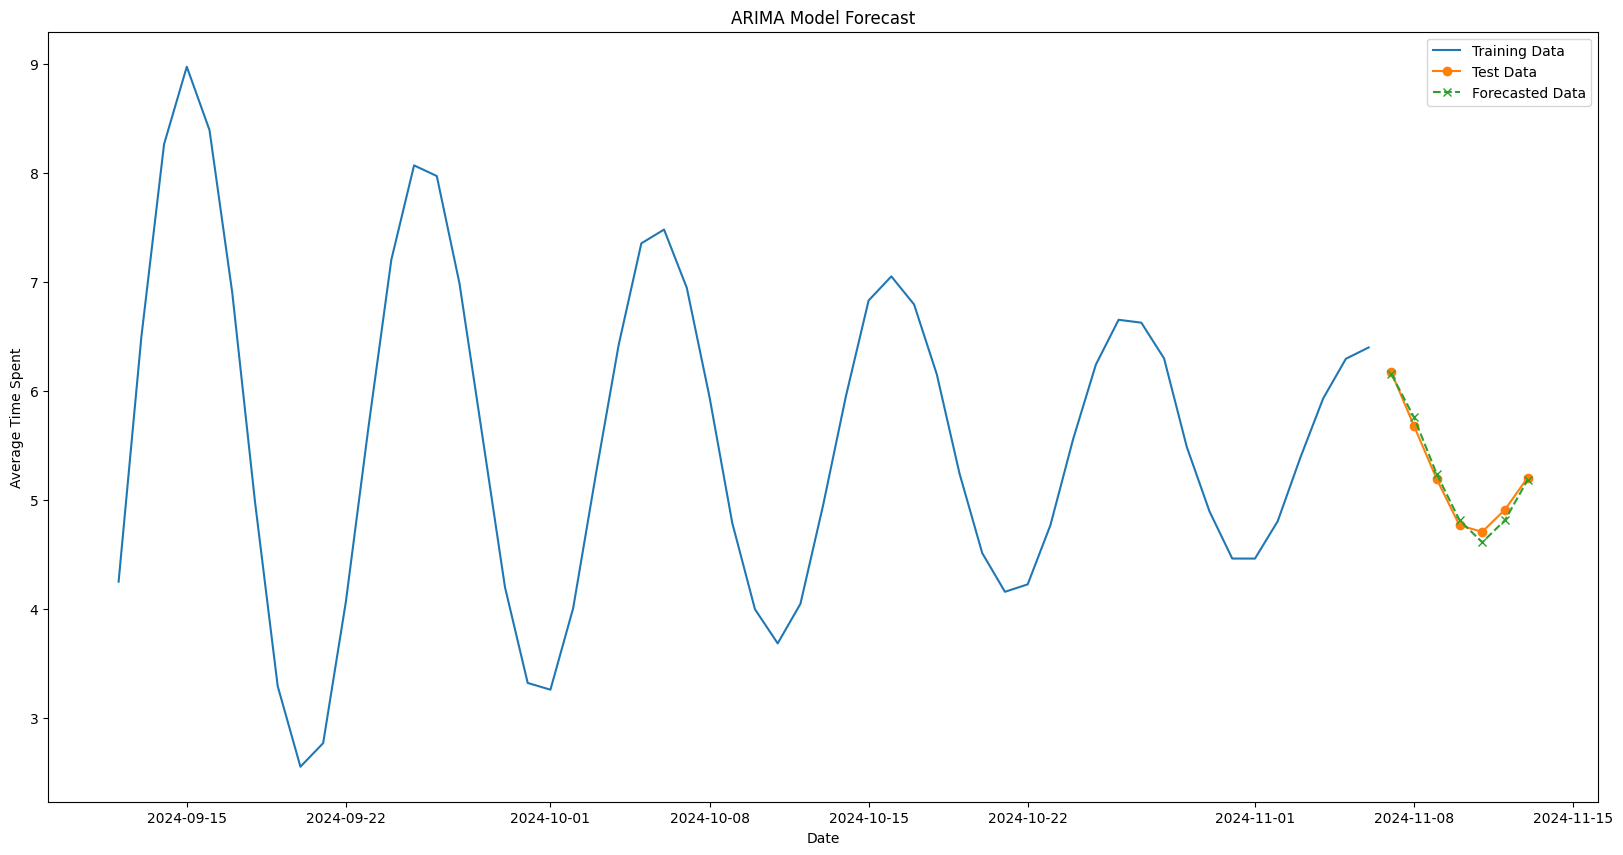

In [9]:
forecast_days = np.arange(1, 8)
# print(forecast_days)
forecast=forecaster.predict(forecast_days)
print(forecast)
print(test_data)

plt.figure(figsize=(20, 10))
plt.plot(train_data['date'], train_data['time_spent'], label='Training Data')
plt.plot(test_data['date'], test_data['time_spent'], label='Test Data',marker = 'o')
plt.plot(test_data['date'], forecast, label='Forecasted Data', linestyle='--',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Average Time Spent')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

In [10]:
MASE = mean_absolute_scaled_error(y_train=train_data['time_spent'],y_true=test_data['time_spent'], y_pred=forecast)
MAPE = mean_absolute_percentage_error(test_data['time_spent'], forecast)

print('Mean Absolute Scaled Error:', MASE)
print('Mean Absolute Percentage Error:', MAPE)

Mean Absolute Scaled Error: 0.07529547893049167
Mean Absolute Percentage Error: 0.011459233218897117


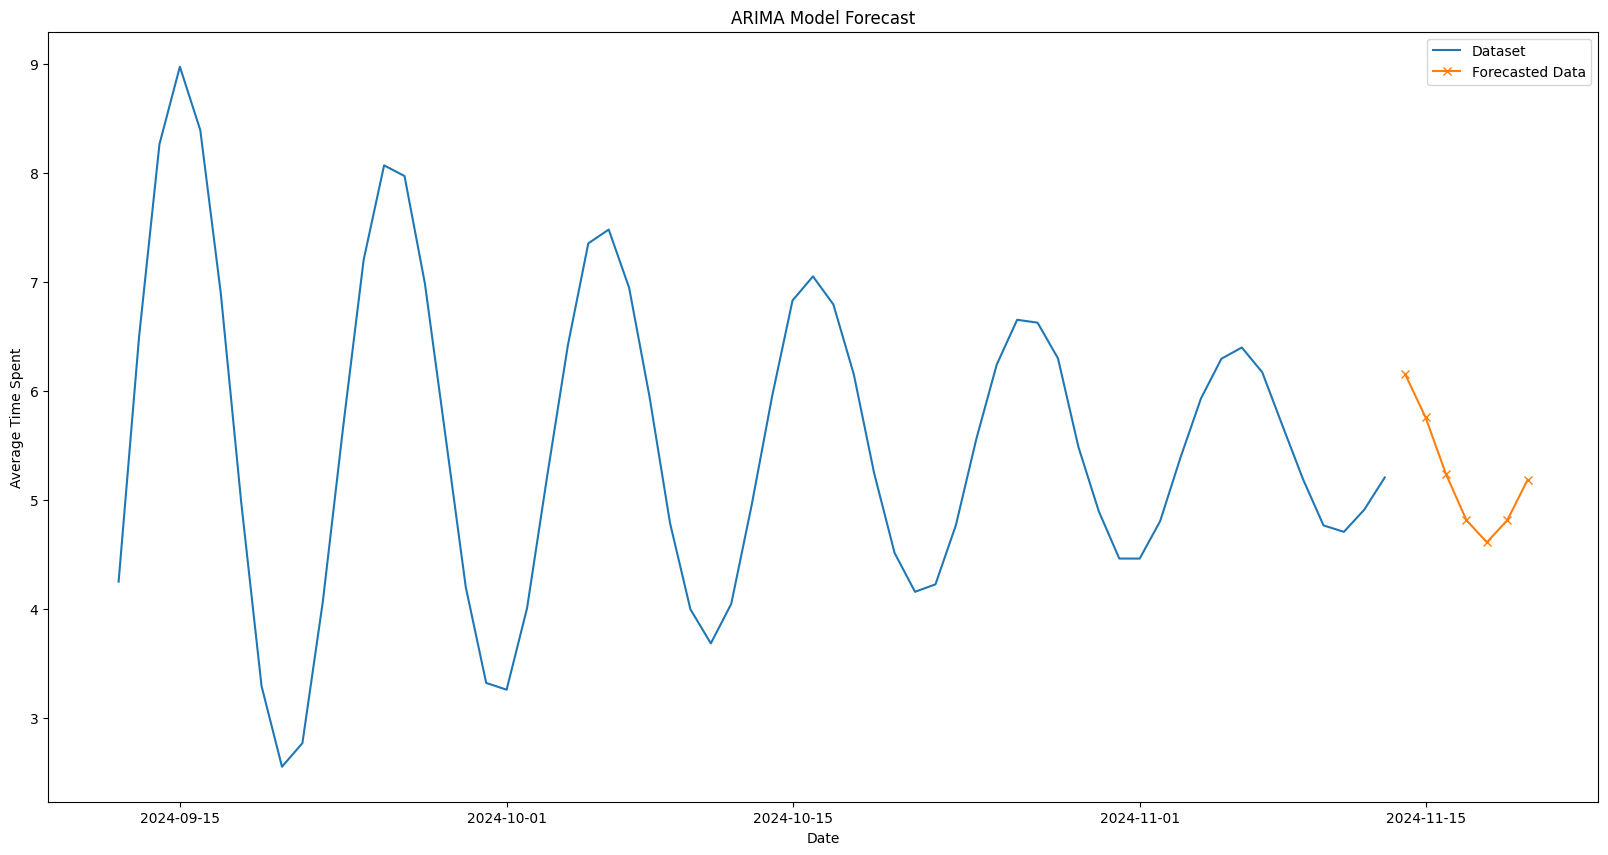

In [11]:
forecast_final = forecaster.predict([8,9,10,11,12,13,14])

last_date = average_time_spent['date'].iloc[-1]
next_7_days = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)
plt.figure(figsize=(20, 10))
plt.plot(average_time_spent['date'], average_time_spent['time_spent'], label='Dataset')
plt.plot(next_7_days, forecast, label='Forecasted Data', linestyle='-',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Average Time Spent')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

